<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab3A_Data_Input_EDA_Model_Comparison_COLAB_VSCODE_2026_05_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Lab 3A: Python Data Input, EDA, and First Model Comparison

**Date/time:** Thursday, 7 May 2026, 16:00  
**Room:** Comp. Lab 1  
**Topic:** Colab demonstration with Visual Studio Code remarks

This notebook uses only built-in Python modules for the core workflow. That reduces package-installation problems in Visual Studio Code. Colab users may still use `pandas` later, but this lab first makes the file path and data structure clear.

## 0. Colab versus Visual Studio Code

### Colab
- Python runs on a temporary cloud computer.
- Quick upload files usually appear in `/content`.
- Google Drive files appear under `/content/drive/MyDrive/...` after mounting Drive.

### Visual Studio Code
- Python runs on your computer.
- The current working directory is usually the folder opened in VS Code.
- Recommended layout:

```text
AKHU_lab3/
  Lab3A.ipynb
  Lab3B.ipynb
  data/
    AKHU_student_scores_cs_lab3_clean.csv
    AKHU_student_scores_cs_lab3_messy.csv
```

Run `Path.cwd()` before loading data. This single habit prevents many file-loading errors.

In [13]:
from pathlib import Path
import csv
import statistics
import math

print("Current working directory:", Path.cwd())

# Colab notes:
# 1. Quick demo: upload CSV files to /content.
# 2. Persistent demo: mount Google Drive and put files in /content/drive/MyDrive/AKHU_labs.
#
# Uncomment these lines only inside Colab when you want to mount Google Drive:
# from google.colab import drive
# drive.mount("/content/drive")

CANDIDATE_DIRS = [
    Path("data"),
    Path("."),
    Path("/content"),
    Path("/content/data"),
    Path("/content/drive/MyDrive/AKHU_labs"),
]

def find_data_file(filename):
    for folder in CANDIDATE_DIRS:
        candidate = folder / filename
        if candidate.exists():
            print(f"Found {filename} at: {candidate}")
            return candidate
    searched = "\n".join(str(folder.resolve()) if folder.exists() else str(folder) for folder in CANDIDATE_DIRS)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

Current working directory: /content


## 0A. Plotting support for lecture-note figures

The following figure cells do two things:

1. show each figure directly inside this notebook; and
2. save a PNG copy into the `assets/` folder so the same figure can be used in the lecture note.

**Colab note.** After a figure cell runs, the image should appear immediately below the cell output.  
**VS Code note.** If no figure appears, install or enable the Python/Jupyter extension and make sure `matplotlib` is available.

In [14]:
ASSETS_DIR = Path("assets")
ASSETS_DIR.mkdir(exist_ok=True)

try:
    # Use a non-interactive backend so the same notebook runs reliably in Colab,
    # Jupyter, and VS Code. The saved PNG is displayed explicitly below.
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
    print("matplotlib is available. Figures will be displayed below the code cell and saved in:", ASSETS_DIR.resolve())
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False
    print("matplotlib is not installed. Core analysis will still run.")
    print("In Colab, matplotlib is usually available. In VS Code, install it only if your teacher asks for plots.")

try:
    from IPython.display import Image, display
    HAS_IPYTHON_DISPLAY = True
except Exception:
    Image = None
    display = None
    HAS_IPYTHON_DISPLAY = False


def save_and_show_current_figure(filename):
    """Save the current matplotlib figure and show the saved PNG inside the notebook."""
    path = ASSETS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()
    print("Saved figure:", path)

    # In Colab/Jupyter/VS Code notebooks, display the PNG directly below the code cell.
    if HAS_IPYTHON_DISPLAY:
        display(Image(filename=str(path)))
    else:
        print("Open this file to view the figure:", path)


matplotlib is available. Figures will be displayed below the code cell and saved in: /content/assets


### Create the setup and workflow figures

These two diagrams correspond to the lecture-note figures:

```text
assets/colab_vs_vscode_paths.png
assets/day1_workflow.png
```

They are concept figures, not data plots. They explain where files live and how a CSV becomes rows that Python can analyze.

Saved figure: assets/colab_vs_vscode_paths.png


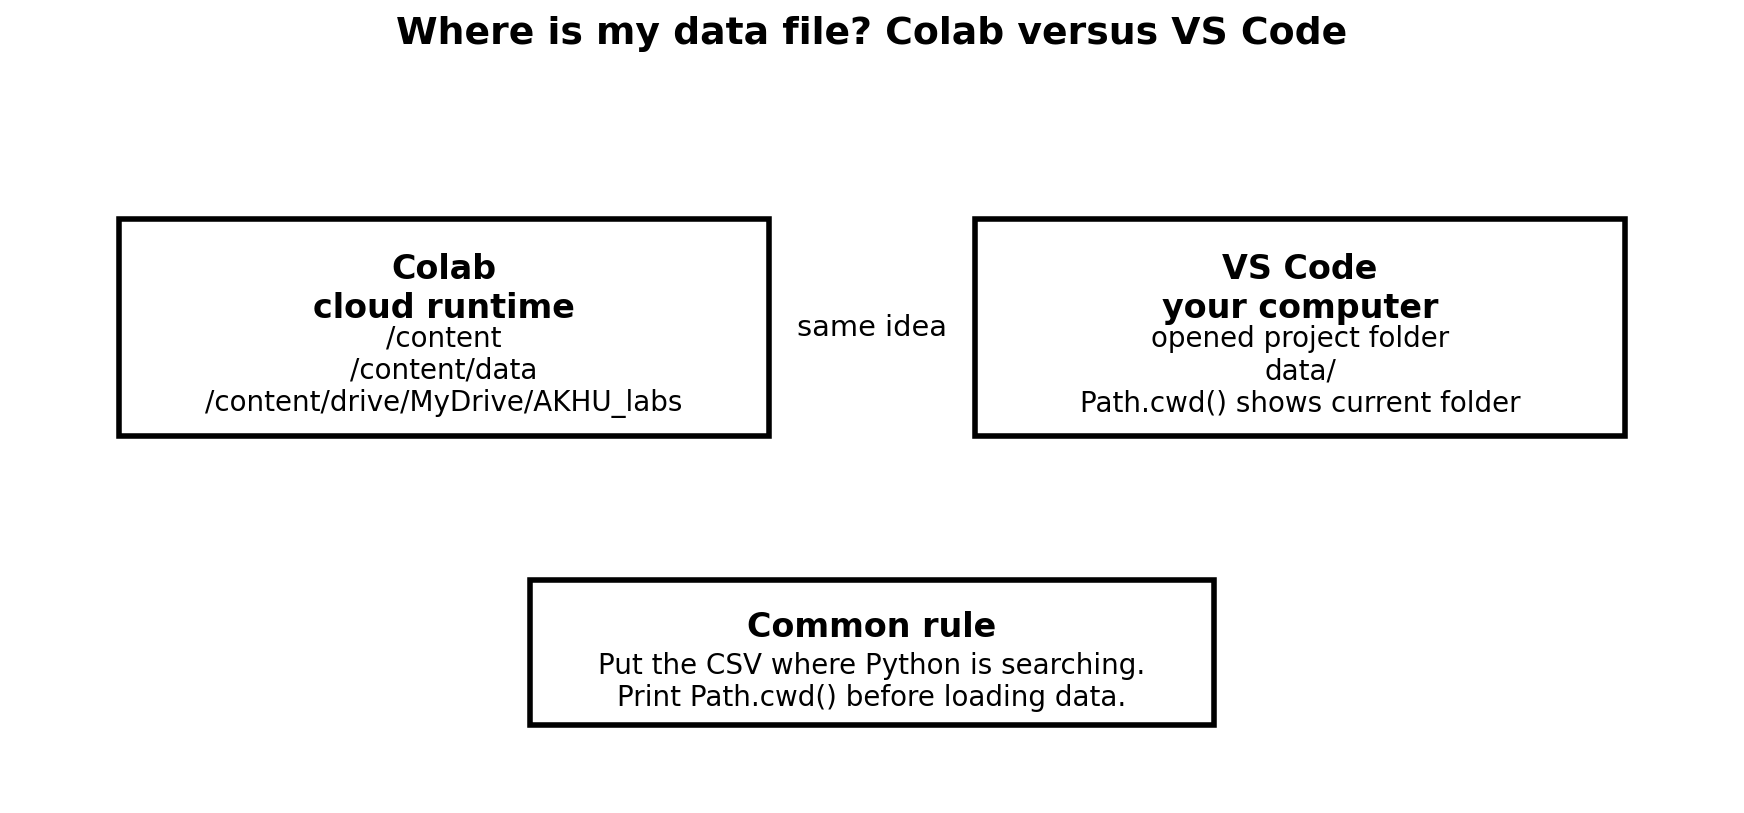

Saved figure: assets/day1_workflow.png


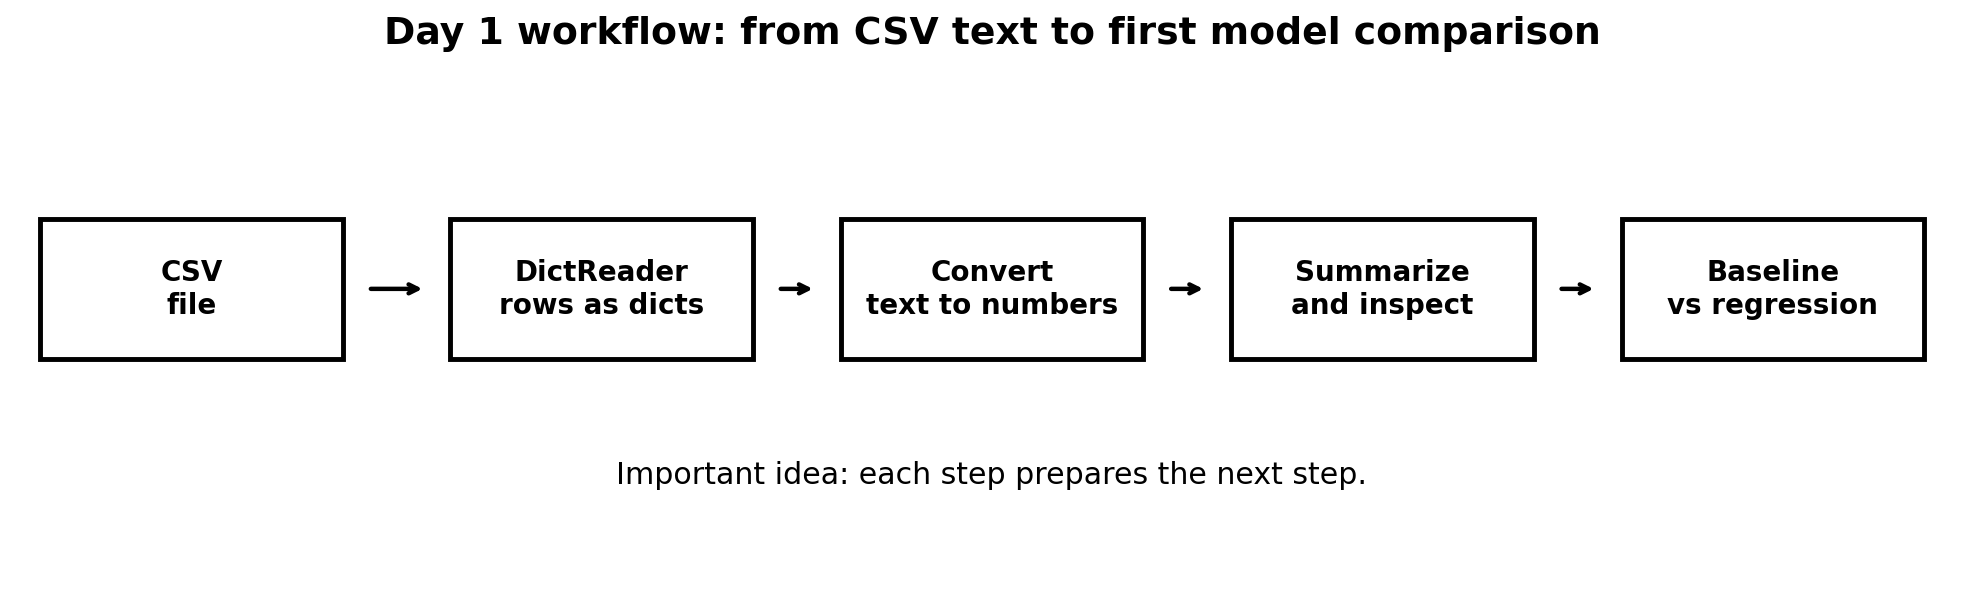

In [15]:
if HAS_MATPLOTLIB:
    # Figure 1: Colab versus VS Code paths
    fig, ax = plt.subplots(figsize=(11, 5.2))
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Where is my data file? Colab versus VS Code", fontsize=17, weight="bold", pad=14)

    boxes = [
        (0.06, 0.50, 0.38, 0.30, "Colab\ncloud runtime", "/content\n/content/data\n/content/drive/MyDrive/AKHU_labs"),
        (0.56, 0.50, 0.38, 0.30, "VS Code\nyour computer", "opened project folder\ndata/\nPath.cwd() shows current folder"),
        (0.30, 0.10, 0.40, 0.20, "Common rule", "Put the CSV where Python is searching.\nPrint Path.cwd() before loading data."),
    ]
    for x, y, w, h, title, body in boxes:
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, linewidth=2.5))
        ax.text(x + w/2, y + h*0.68, title, ha="center", va="center", fontsize=15, weight="bold")
        ax.text(x + w/2, y + h*0.30, body, ha="center", va="center", fontsize=12.5)
    ax.text(0.50, 0.65, "same idea", ha="center", va="center", fontsize=13)
    save_and_show_current_figure("colab_vs_vscode_paths.png")

    # Figure 2: Day 1 workflow
    fig, ax = plt.subplots(figsize=(12.5, 3.8))
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Day 1 workflow: from CSV text to first model comparison", fontsize=17, weight="bold", pad=14)

    steps = [
        "CSV\nfile",
        "DictReader\nrows as dicts",
        "Convert\ntext to numbers",
        "Summarize\nand inspect",
        "Baseline\nvs regression",
    ]
    xs = [0.09, 0.30, 0.50, 0.70, 0.90]
    box_w = 0.155
    box_h = 0.28
    y0 = 0.43
    for i, (x, label) in enumerate(zip(xs, steps)):
        ax.add_patch(plt.Rectangle((x - box_w/2, y0), box_w, box_h, fill=False, linewidth=2.2))
        ax.text(x, y0 + box_h/2, label, ha="center", va="center", fontsize=12.5, weight="bold")
        if i < len(xs) - 1:
            ax.annotate("", xy=(xs[i+1] - box_w/2 - 0.012, y0 + box_h/2),
                        xytext=(x + box_w/2 + 0.012, y0 + box_h/2),
                        arrowprops=dict(arrowstyle="->", linewidth=2))
    ax.text(0.5, 0.18, "Important idea: each step prepares the next step.", ha="center", fontsize=13.5)
    save_and_show_current_figure("day1_workflow.png")
else:
    print("Skipping setup/workflow figures because matplotlib is not available.")

**Figure preview.** The previous code cell creates and saves the following figure(s). They are also embedded here so the notebook shows the lecture figures immediately.

**Colab versus VS Code path locations**

![Colab versus VS Code path locations](attachment:colab_vs_vscode_paths.png)

**Day 1 workflow**

![Day 1 workflow](attachment:day1_workflow.png)

## 1. Find and read the clean CSV file

The CSV file is a rectangular table: rows are students and columns are variables.
Python's built-in `csv.DictReader` reads each row as a dictionary.

In [16]:
clean_path = find_data_file("AKHU_student_scores_cs_lab3_clean.csv")

with clean_path.open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    column_names = reader.fieldnames

print("Number of rows:", len(rows))
print("Column names:", column_names)
print("First row:")
print(rows[0])

Found AKHU_student_scores_cs_lab3_clean.csv at: AKHU_student_scores_cs_lab3_clean.csv
Number of rows: 12
Column names: ['student_id', 'hours_studied', 'attendance_rate', 'assignments_submitted', 'quiz_average', 'final_score']
First row:
{'student_id': 'S01', 'hours_studied': '1.5', 'attendance_rate': '0.55', 'assignments_submitted': '4', 'quiz_average': '48', 'final_score': '52'}


## 2. Convert selected columns from text to numbers

CSV cells are read as text. Modeling requires numbers. We convert only the columns needed today.

In [17]:
NUMERIC_COLUMNS = ["hours_studied", "attendance_rate", "assignments_submitted", "quiz_average", "final_score"]

for row in rows:
    for col in NUMERIC_COLUMNS:
        row[col] = float(row[col])

print(rows[0])
print("Type of final_score after conversion:", type(rows[0]["final_score"]))

{'student_id': 'S01', 'hours_studied': 1.5, 'attendance_rate': 0.55, 'assignments_submitted': 4.0, 'quiz_average': 48.0, 'final_score': 52.0}
Type of final_score after conversion: <class 'float'>


## 3. EDA: numerical summaries

EDA means exploratory data analysis. Start with simple questions:

- What is the average final score?
- How spread out are the scores?
- What are the minimum and maximum scores?

In [18]:
def summarize_column(rows, column):
    values = [row[column] for row in rows]
    return {
        "count": len(values),
        "mean": statistics.mean(values),
        "median": statistics.median(values),
        "min": min(values),
        "max": max(values),
        "std": statistics.stdev(values),
    }

summary = summarize_column(rows, "final_score")
for key, value in summary.items():
    print(f"{key:>6}: {value:.3f}" if isinstance(value, float) else f"{key:>6}: {value}")

 count: 12
  mean: 68.917
median: 69.000
   min: 52.000
   max: 87.000
   std: 11.082


## 4. EDA: relationship question

Question: Does `hours_studied` move together with `final_score`?

Without plotting packages, we can print pairs. In Colab, the instructor may also display plots from the lecture note.

In [19]:
for row in rows:
    print(row["student_id"], "hours =", row["hours_studied"], "final_score =", row["final_score"])

S01 hours = 1.5 final_score = 52.0
S02 hours = 2.0 final_score = 56.0
S03 hours = 2.3 final_score = 59.0
S04 hours = 2.7 final_score = 63.0
S05 hours = 3.0 final_score = 67.0
S06 hours = 3.3 final_score = 71.0
S07 hours = 3.5 final_score = 73.0
S08 hours = 3.8 final_score = 76.0
S09 hours = 4.0 final_score = 79.0
S10 hours = 4.2 final_score = 83.0
S11 hours = 4.4 final_score = 87.0
S12 hours = 2.2 final_score = 61.0


## 4A. Create EDA figures from the data

The lecture note shows two EDA figures. This notebook now creates them directly from the loaded CSV:

```text
assets/eda_final_score_bar.png
assets/eda_hours_vs_score.png
```

The first plot shows each student's final score. The second plot checks whether `hours_studied` and `final_score` move together.

Saved figure: assets/eda_final_score_bar.png


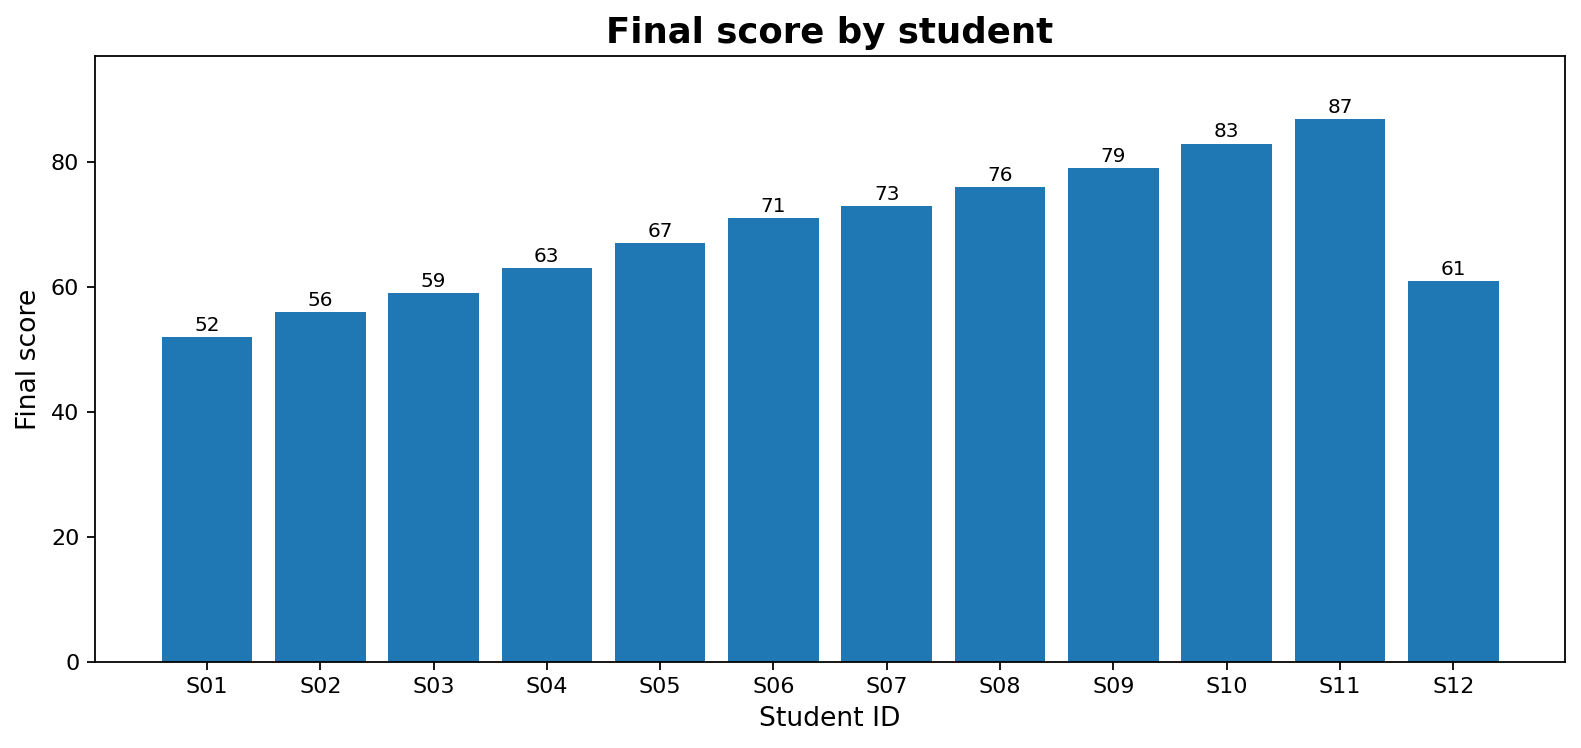

Saved figure: assets/eda_hours_vs_score.png


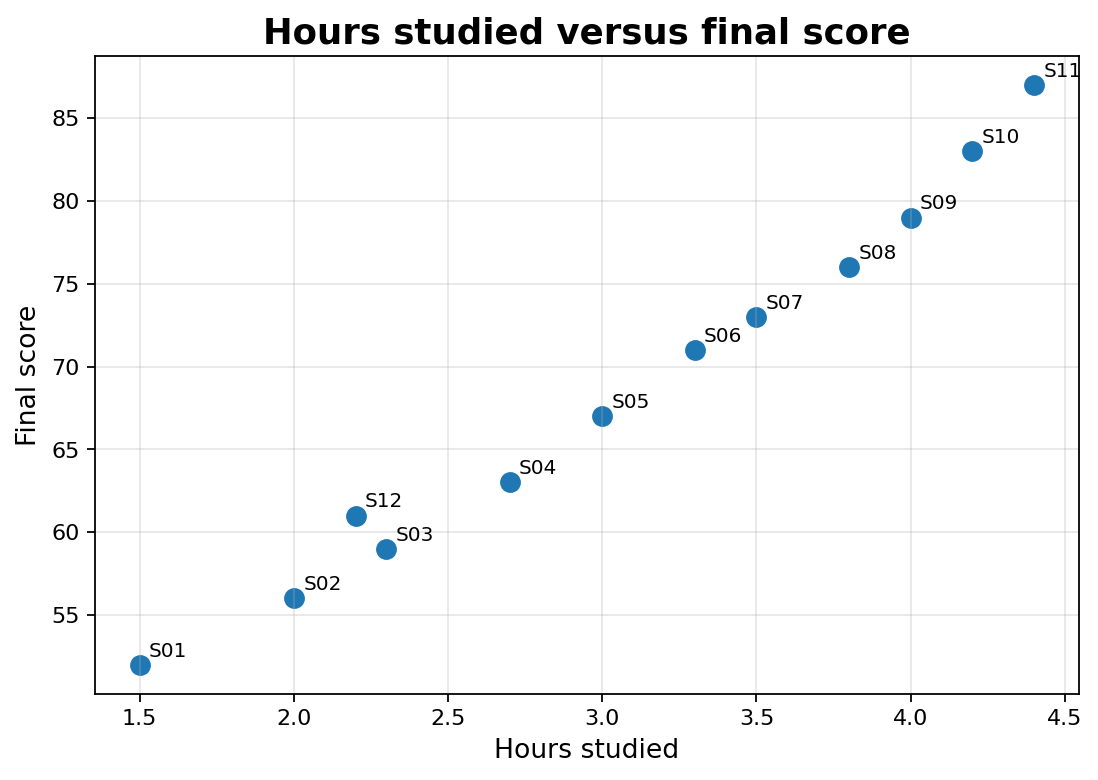

In [20]:
if HAS_MATPLOTLIB:
    student_ids = [row["student_id"] for row in rows]
    final_scores = [row["final_score"] for row in rows]
    hours = [row["hours_studied"] for row in rows]

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.bar(student_ids, final_scores)
    ax.set_title("Final score by student", fontsize=16, weight="bold")
    ax.set_xlabel("Student ID", fontsize=12)
    ax.set_ylabel("Final score", fontsize=12)
    ax.set_ylim(0, max(final_scores) + 10)
    for i, score in enumerate(final_scores):
        ax.text(i, score + 1, f"{score:.0f}", ha="center", fontsize=9)
    save_and_show_current_figure("eda_final_score_bar.png")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(hours, final_scores, s=70)
    for sid, x, y in zip(student_ids, hours, final_scores):
        ax.text(x + 0.03, y + 0.5, sid, fontsize=9)
    ax.set_title("Hours studied versus final score", fontsize=16, weight="bold")
    ax.set_xlabel("Hours studied", fontsize=12)
    ax.set_ylabel("Final score", fontsize=12)
    ax.grid(True, alpha=0.3)
    save_and_show_current_figure("eda_hours_vs_score.png")
else:
    print("Skipping EDA figures because matplotlib is not available.")
    print("Text fallback: print student_id, hours_studied, and final_score in the previous cell.")

**Figure preview.** The previous code cell creates and saves the following figure(s). They are also embedded here so the notebook shows the lecture figures immediately.

**Final score by student**

![Final score by student](attachment:eda_final_score_bar.png)

**Hours studied versus final score**

![Hours studied versus final score](attachment:eda_hours_vs_score.png)

## 5. First model comparison: mean baseline versus simple regression

We use the first 8 rows for training and the last 4 rows for testing.

### Mean baseline
Predict the training mean for every test row.

### Simple regression
Use one feature, `hours_studied`, to predict `final_score`:

\[
\hat{y} = b_0 + b_1 x
\]

In [21]:
def train_test_split(rows, n_train=8):
    return rows[:n_train], rows[n_train:]

def mean_baseline_fit(train_rows, target_col):
    return statistics.mean(row[target_col] for row in train_rows)

def mean_baseline_predict(mean_value, test_rows):
    return [mean_value for _ in test_rows]

def simple_regression_fit(train_rows, x_col, y_col):
    x = [row[x_col] for row in train_rows]
    y = [row[y_col] for row in train_rows]
    x_bar = statistics.mean(x)
    y_bar = statistics.mean(y)
    numerator = sum((xi - x_bar) * (yi - y_bar) for xi, yi in zip(x, y))
    denominator = sum((xi - x_bar) ** 2 for xi in x)
    slope = numerator / denominator
    intercept = y_bar - slope * x_bar
    return intercept, slope

def simple_regression_predict(intercept, slope, test_rows, x_col):
    return [intercept + slope * row[x_col] for row in test_rows]

def mae(actual, predicted):
    return sum(abs(a - p) for a, p in zip(actual, predicted)) / len(actual)

def rmse(actual, predicted):
    return math.sqrt(sum((a - p) ** 2 for a, p in zip(actual, predicted)) / len(actual))

In [22]:
train_rows, test_rows = train_test_split(rows, n_train=8)
y_test = [row["final_score"] for row in test_rows]

mean_value = mean_baseline_fit(train_rows, "final_score")
baseline_pred = mean_baseline_predict(mean_value, test_rows)

intercept, slope = simple_regression_fit(train_rows, "hours_studied", "final_score")
regression_pred = simple_regression_predict(intercept, slope, test_rows, "hours_studied")

print("Regression equation:")
print(f"predicted final_score = {intercept:.3f} + {slope:.3f} * hours_studied")
print()
print("Model comparison")
print("Mean baseline MAE:", round(mae(y_test, baseline_pred), 3))
print("Mean baseline RMSE:", round(rmse(y_test, baseline_pred), 3))
print("Regression MAE:", round(mae(y_test, regression_pred), 3))
print("Regression RMSE:", round(rmse(y_test, regression_pred), 3))

Regression equation:
predicted final_score = 34.718 + 10.826 * hours_studied

Model comparison
Mean baseline MAE: 14.688
Mean baseline RMSE: 16.264
Regression MAE: 2.726
Regression RMSE: 3.022


## 5A. Create model-comparison figures

After the model comparison is computed, the notebook can create the same comparison figures used in the lecture note:

```text
assets/model_comparison_mae.png
assets/actual_vs_predicted_test.png
```

The important reading rule is simple: lower MAE is better, and predictions closer to the actual value are better.

Saved figure: assets/model_comparison_mae.png


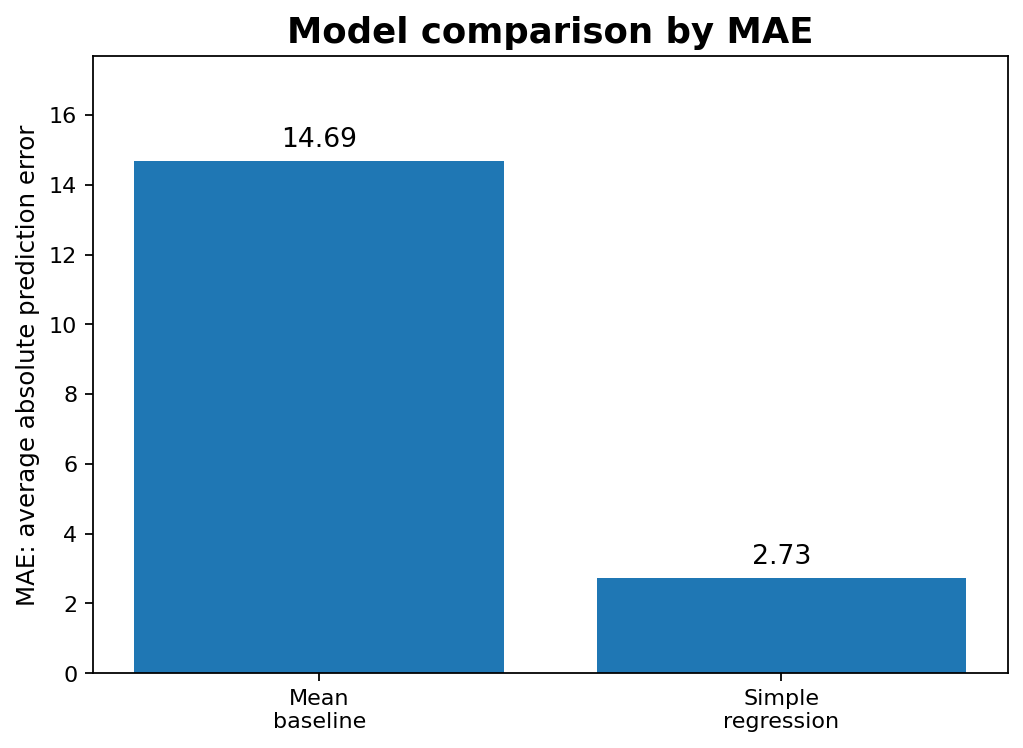

Saved figure: assets/actual_vs_predicted_test.png


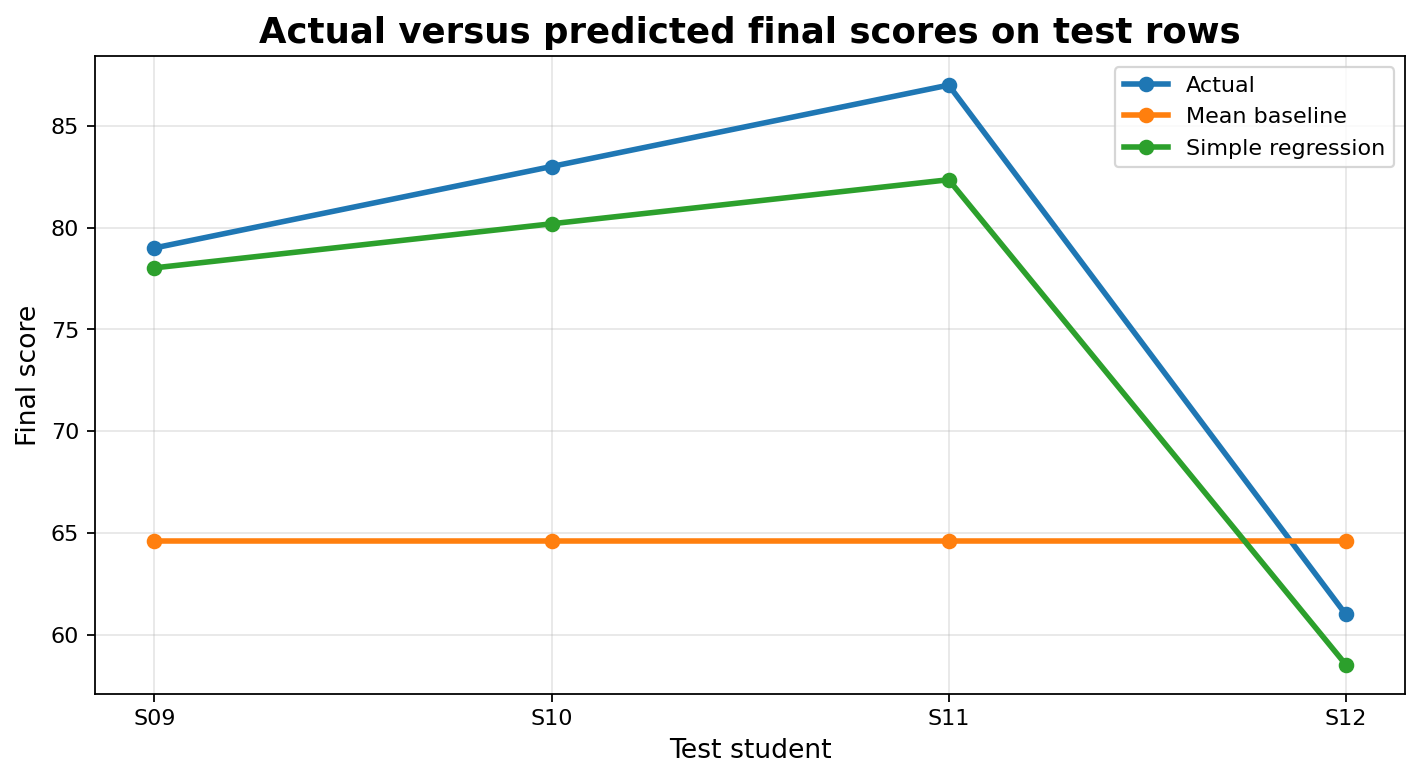

In [23]:
if HAS_MATPLOTLIB:
    baseline_mae = mae(y_test, baseline_pred)
    regression_mae = mae(y_test, regression_pred)

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    model_names = ["Mean\nbaseline", "Simple\nregression"]
    mae_values = [baseline_mae, regression_mae]
    bars = ax.bar(model_names, mae_values)
    ax.set_title("Model comparison by MAE", fontsize=16, weight="bold")
    ax.set_ylabel("MAE: average absolute prediction error", fontsize=11)
    ax.set_ylim(0, max(mae_values) + 3)
    for bar, value in zip(bars, mae_values):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.4, f"{value:.2f}", ha="center", fontsize=12)
    save_and_show_current_figure("model_comparison_mae.png")

    fig, ax = plt.subplots(figsize=(9, 5))
    test_ids = [row["student_id"] for row in test_rows]
    x_positions = list(range(len(test_ids)))
    ax.plot(x_positions, y_test, marker="o", linewidth=2.5, label="Actual")
    ax.plot(x_positions, baseline_pred, marker="o", linewidth=2.5, label="Mean baseline")
    ax.plot(x_positions, regression_pred, marker="o", linewidth=2.5, label="Simple regression")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(test_ids)
    ax.set_title("Actual versus predicted final scores on test rows", fontsize=16, weight="bold")
    ax.set_xlabel("Test student", fontsize=12)
    ax.set_ylabel("Final score", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_and_show_current_figure("actual_vs_predicted_test.png")
else:
    print("Skipping model-comparison figures because matplotlib is not available.")
    print("Text fallback: use the prediction table and printed MAE/RMSE values.")

**Figure preview.** The previous code cell creates and saves the following figure(s). They are also embedded here so the notebook shows the lecture figures immediately.

**Model comparison by MAE**

![Model comparison by MAE](attachment:model_comparison_mae.png)

**Actual versus predicted test rows**

![Actual versus predicted test rows](attachment:actual_vs_predicted_test.png)

## 6. Prediction table

Read the table row by row. Which prediction is closer to the actual score?

In [24]:
print(f"{'ID':<5}{'Actual':>10}{'Baseline':>12}{'Regression':>14}")
for row, actual, base_p, reg_p in zip(test_rows, y_test, baseline_pred, regression_pred):
    print(f"{row['student_id']:<5}{actual:>10.1f}{base_p:>12.1f}{reg_p:>14.1f}")

ID       Actual    Baseline    Regression
S09        79.0        64.6          78.0
S10        83.0        64.6          80.2
S11        87.0        64.6          82.4
S12        61.0        64.6          58.5


## 7. Your turn

1. Change the regression feature from `hours_studied` to `quiz_average`.
2. Recompute MAE.
3. Which one-feature regression is better on the test rows?

Hint:

```python
intercept, slope = simple_regression_fit(train_rows, "quiz_average", "final_score")
quiz_pred = simple_regression_predict(intercept, slope, test_rows, "quiz_average")
print(mae(y_test, quiz_pred))
```